---
title: "Interpreting Time-Series Forecasts with TabPFN-TS"
description: "Explain what drives a TabPFN-TS forecast with partial dependence, Window SHAP, and time-series decomposition"
cookbookTags:
  - interpretability
authors:
  - name: Prior Labs
    linkedin: https://www.linkedin.com/company/prior-labs
    twitter: https://twitter.com/prior_labs
---

*With partial dependence, Window SHAP, and additive decomposition.*

Forecasts that we cannot explain rarely help us make better decisions. In this notebook, we forecast German day-ahead electricity prices and then explain the results with three different methods:

- Partial Dependence Plots: to understand how the forecast reacts to different feature values
- Window SHAP: SHAP values of different features and feature groups over time
- Series Decomposition: plotting the different components (trend, seasonality and residuals) of the series

With this electricity use-case, it is easy to understand how different factors affect the price. Electricity demand is seasonal, we see hour-of-day and weekday patterns. Demand increases prices, supply (solar+wind) decreases prices. Let's start interpreting some forecasts!

## Setup

*Installing TabPFN-TS with its optional explainability tools.*

The explainability extra includes `shapiq` for grouped Shapley values and Matplotlib for the plotting helpers. `pyarrow` is used to read the compact Parquet dataset.

In [1]:
!pip install "tabpfn-time-series[explainability]" pyarrow

  Using cached tabpfn_client-0.4.2-py3-none-any.whl.metadata (14 kB)
  Using cached shapiq-1.4.1-py3-none-any.whl.metadata (39 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
INFO: pip is looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached huggingface_hub-1.14.0-py3-none-any.whl.metadata (14 kB

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tabpfn_time_series import TabPFNMode, TabPFNTSPipeline
from tabpfn_time_series.explainability import (
    TabPFNTSExplainer,
    plot_decomposition,
    plot_pdp_grid,
    plot_window_shap_spectrogram,
)

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})

## Loading the Data

*Two weeks of hourly German electricity prices, demand, and renewable generation.*

The target is the German day-ahead electricity price. We use both time-based features computed automatically by the `TabPFNTSPipeline` and two known covariates: Amprion's load to model demand and combined photovoltaic and wind forecast to model supply.

In [3]:
DATA_URL = (
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/"
    "electricity_price/train.parquet"
)
COVARIATES = ["Amprion Load Forecast", "PV+Wind Forecast"]

raw = pd.read_parquet(DATA_URL)
electricity = (
    raw.loc[raw["id"] == "DE"]
    .assign(timestamp=lambda frame: pd.to_datetime(frame["timestamp"]))
    .sort_values("timestamp")
    .head(360)
    .drop(columns="id")
    .rename(columns={"Ampirion Load Forecast": "Amprion Load Forecast"})
    .reset_index(drop=True)
)

print(
    f"Loaded {len(electricity)} hourly observations from "
    f"{electricity.timestamp.min():%d %b} to {electricity.timestamp.max():%d %b %Y}."
)

Loaded 360 hourly observations from 09 Jan to 23 Jan 2012.


### Visualising the series

We start by plotting the data. We can see seasonal patterns with some shocks, including a negative price event.

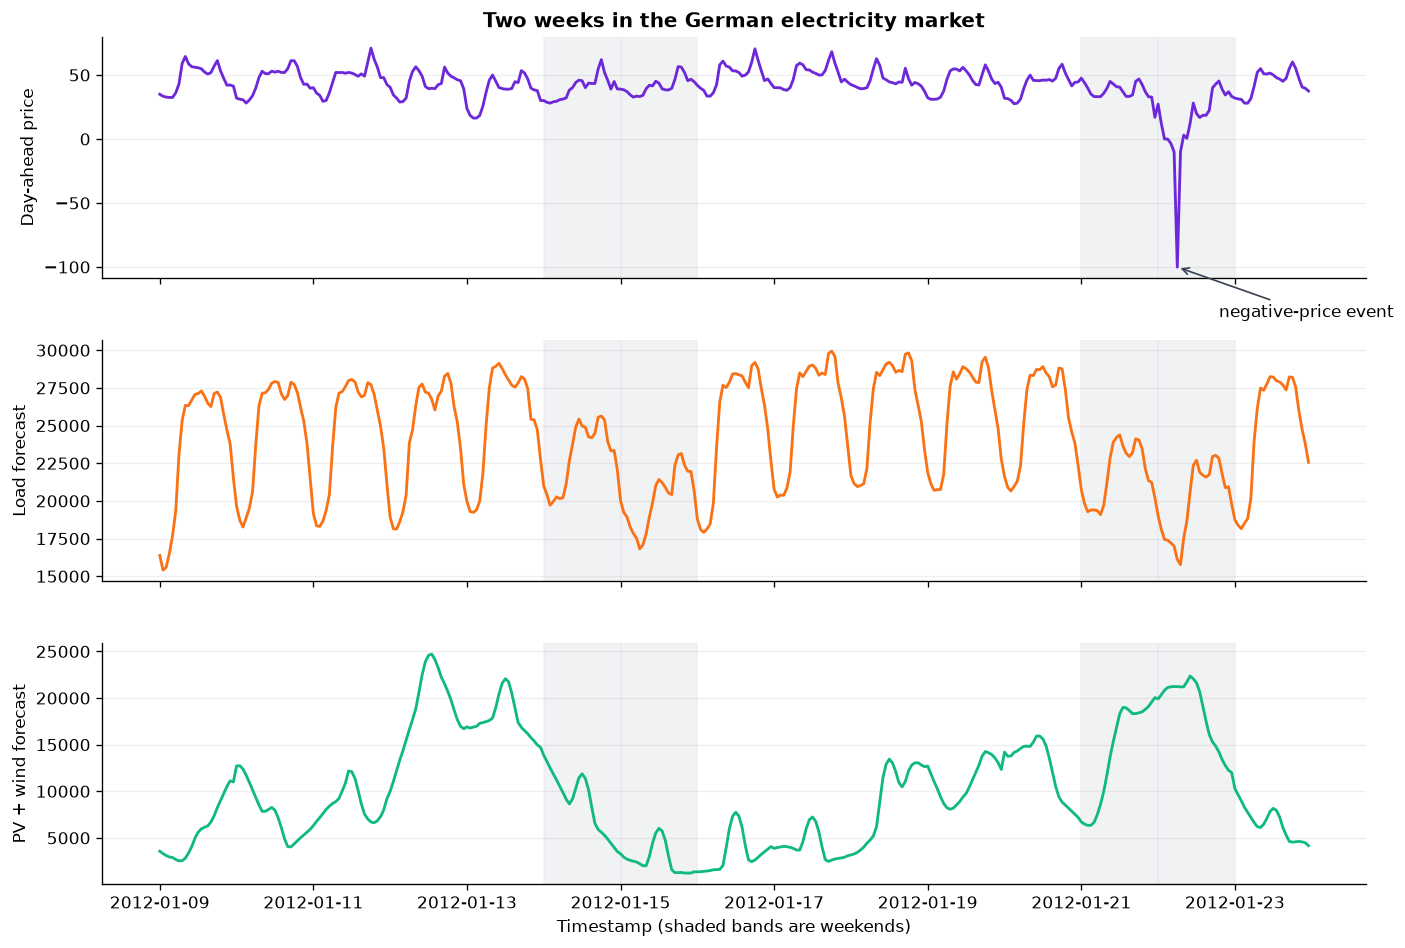

In [4]:
COLORS = {
    "target": "#6D28D9",
    "Amprion Load Forecast": "#F97316",
    "PV+Wind Forecast": "#10B981",
}
LABELS = {
    "target": "Day-ahead price",
    "Amprion Load Forecast": "Load forecast",
    "PV+Wind Forecast": "PV + wind forecast",
}

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, column in zip(axes, ["target", *COVARIATES]):
    ax.plot(
        electricity["timestamp"], electricity[column],
        color=COLORS[column], linewidth=1.7,
    )
    ax.set_ylabel(LABELS[column])
    ax.grid(axis="y", alpha=0.2)

for day in pd.date_range(
    electricity.timestamp.min().normalize(),
    electricity.timestamp.max().normalize(),
    freq="D",
):
    if day.dayofweek >= 5:
        for ax in axes:
            ax.axvspan(day, day + pd.Timedelta(days=1), color="#E5E7EB", alpha=0.5)

price_low = electricity["target"].idxmin()
axes[0].annotate(
    "negative-price event",
    xy=(electricity.loc[price_low, "timestamp"], electricity.loc[price_low, "target"]),
    xytext=(25, -30), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#374151"},
)
axes[0].set_title("Two weeks in the German electricity market")
axes[-1].set_xlabel("Timestamp (shaded bands are weekends)")
fig.tight_layout()
plt.show()

## Fit and Forecast

*Holding out the final day so the forecast can be seen against reality.*

TabPFN-TS turns the series into a tabular regression problem using calendar, trend, and automatically detected seasonal features. We give it seven days of context and the future load and renewables forecasts, then predict the final 24 hours.

In [5]:
HORIZON = 24
CONTEXT_LENGTH = 168

pipeline = TabPFNTSPipeline(
    tabpfn_mode=TabPFNMode.LOCAL,
    max_context_length=CONTEXT_LENGTH,
    tabpfn_model_config={"device": "auto"},
)
explainer = TabPFNTSExplainer(pipeline)

context = electricity.iloc[-(CONTEXT_LENGTH + HORIZON):-HORIZON].copy()
future = electricity.iloc[-HORIZON:].drop(columns="target").copy()
actual = electricity.iloc[-HORIZON:].copy()
forecast = pipeline.predict_df(context, future_df=future)

Predicting time series: 100%|██████████| 1/1 [00:01<00:00,  1.81s/it]


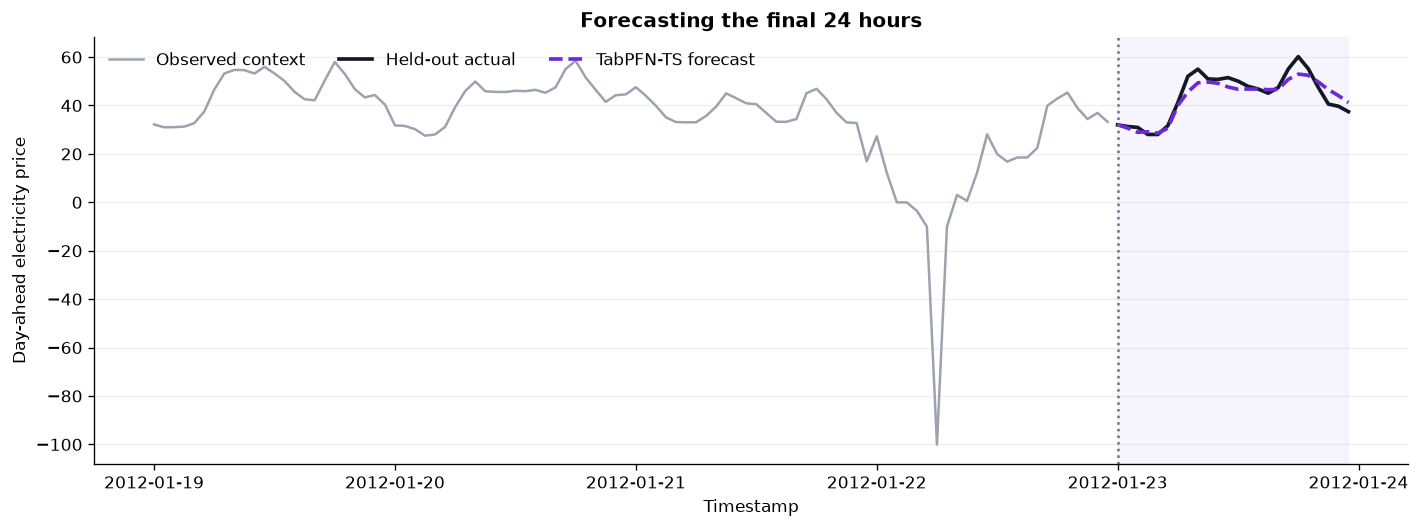

In [6]:
fig, ax = plt.subplots(figsize=(12, 4.5))
visible_context = context.tail(96)
ax.plot(
    visible_context["timestamp"], visible_context["target"],
    color="#9CA3AF", linewidth=1.5, label="Observed context",
)
ax.plot(
    actual["timestamp"], actual["target"],
    color="#111827", linewidth=2.2, label="Held-out actual",
)
ax.plot(
    future["timestamp"], forecast["target"],
    color="#6D28D9", linewidth=2.2, linestyle="--", label="TabPFN-TS forecast",
)
ax.axvspan(future.timestamp.min(), future.timestamp.max(), color="#EDE9FE", alpha=0.45)
ax.axvline(future.timestamp.min(), color="#6B7280", linestyle=":")
ax.set(
    title="Forecasting the final 24 hours",
    xlabel="Timestamp",
    ylabel="Day-ahead electricity price",
)
ax.legend(ncols=3, frameon=False, loc="upper left")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

## Partial Dependence

*How the average forecast changes as one input moves.*

To better understand how the model responds to changes in its features, we built a specific time-series Partial Dependence Plot. We plot the average forecast value over several forecast windows as we change one of the feature values.

We make sure to keep calendar features in the time domain (`hour_of_day`) from 0 to 23, to better understand their impact on the target variable.

Looking at the exogenous variables (Amprion's load and PV+Wind forecasts), we see the relationships that we expect. Higher demand leads to higher prices. Higher supply is associated with lower prices.

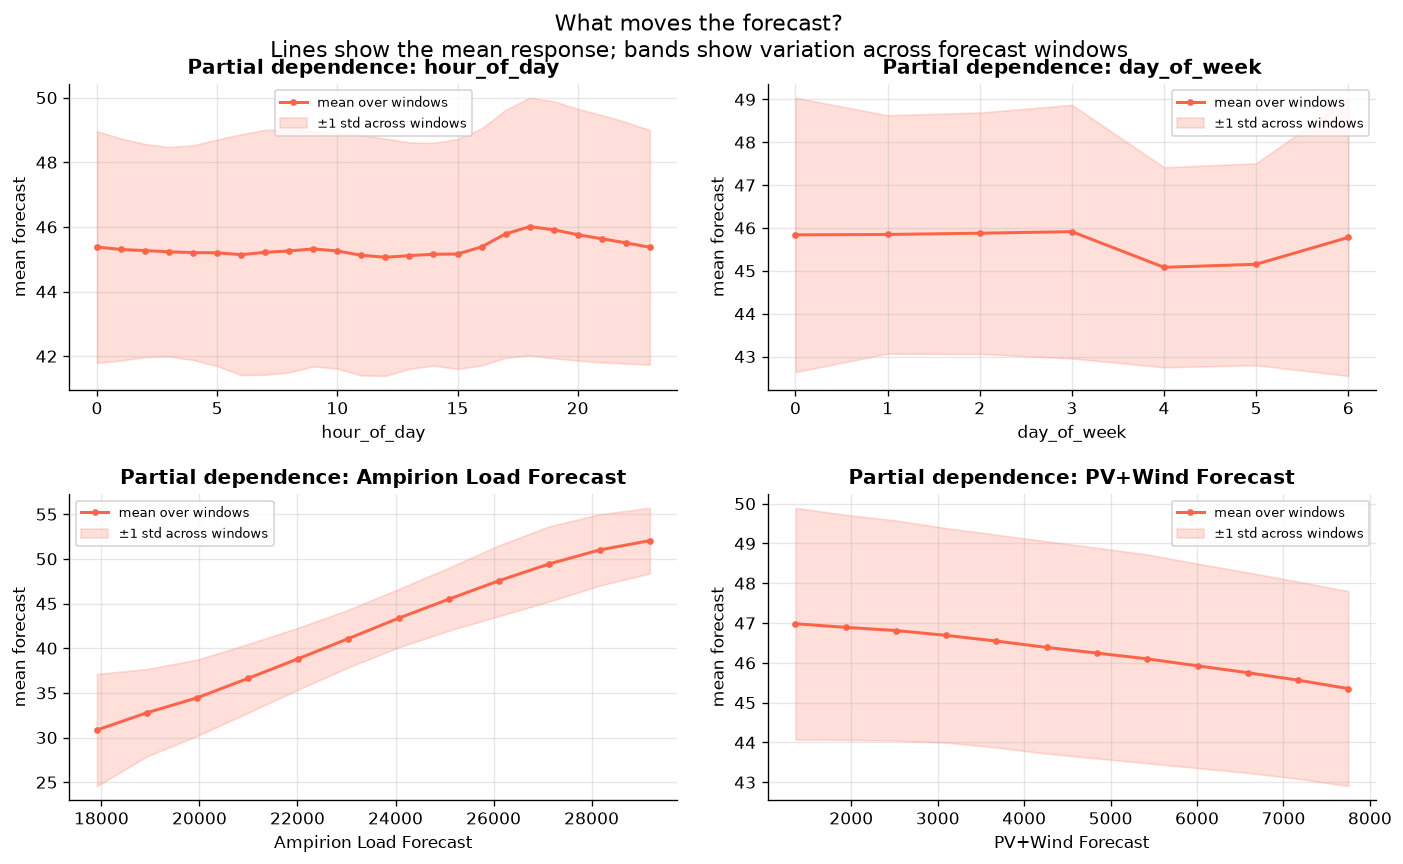

In [7]:
pdps = {}
for feature in ["hour_of_day", "day_of_week", *COVARIATES]:
    pdps[feature] = explainer.partial_dependence(
        electricity,
        feature,
        prediction_length=HORIZON,
        context_length=CONTEXT_LENGTH,
        n_contexts=3,
    )

fig = plot_pdp_grid(pdps, ncols=2)
fig.set_size_inches(12, 7)
fig.suptitle(
    "What moves the forecast?\n"
    "Lines show the mean response; bands show variation across forecast windows",
    y=1.03, fontsize=13,
)
plt.show()

## Window SHAP

*A feature-by-time map of what pushed each forecast up or down.*

The above plots are nice, but they do not tell us what drove the forecast on a given day. To do so, we implemented a Window SHAP that shows SHAP values of different features and feature groups for several time windows. This may remind you of a spectrogram.

The blue cells push the value down, and the red cells push the value up. For example, on the 21st of January, the Amprion Load forecast pushed the forecast value down significantly.

Here again, we made sure to keep calendar columns in the time domain instead of using raw Fourier-based encodings.

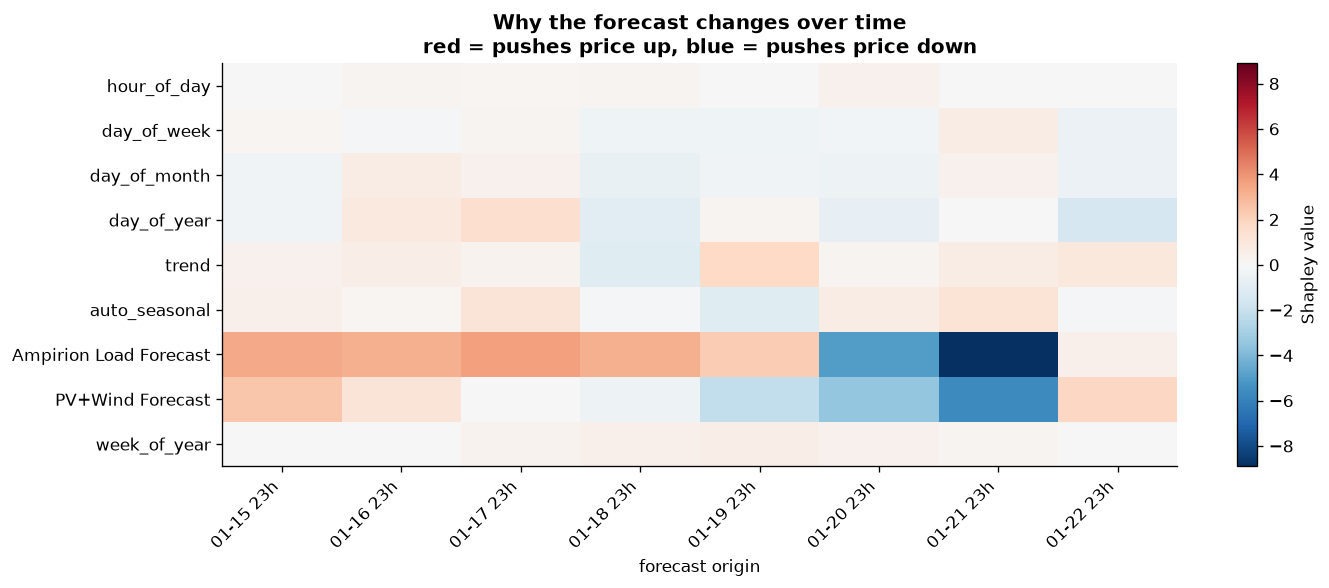

In [8]:
shap_by_window = explainer.window_shap(
    electricity,
    prediction_length=HORIZON,
    context_length=CONTEXT_LENGTH,
    n_windows=8,
    budget=64,
)

fig, ax = plt.subplots(figsize=(12, 5))
plot_window_shap_spectrogram(shap_by_window, ax=ax)
ax.set_title(
    "Why the forecast changes over time\n"
    "red = pushes price up, blue = pushes price down"
)
fig.tight_layout()
plt.show()

### Which groups matter most overall?

*Ranking the same attributions by average absolute contribution.*

Beyond direction, we can also calculate the magnitude of the SHAP values for each feature over the different time windows. This answers the question: which feature groups had the largest influence across all inspected windows?

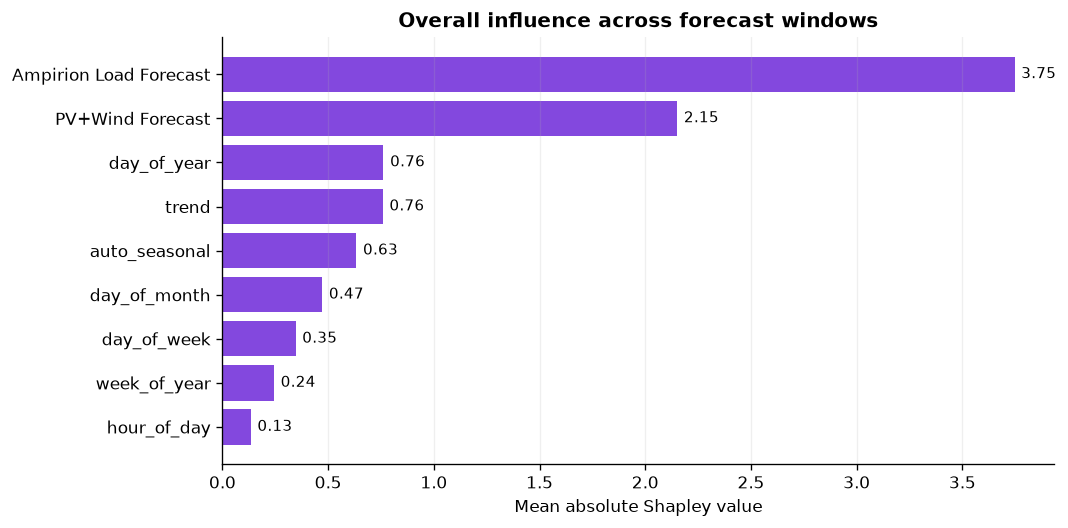

In [9]:
importance = shap_by_window.abs().mean(axis=1).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(importance.index, importance.values, color="#6D28D9", alpha=0.85)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.set(
    title="Overall influence across forecast windows",
    xlabel="Mean absolute Shapley value",
    ylabel="",
)
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()

## Decomposing the Observed Series

*Separating trend, daily rhythm, weekly rhythm, and surprises.*

The previous tools interpret model predictions. Decomposition is a model-free description of the target. It is built using an additive formulation:

`observed = trend + hour_of_day + day_of_week + residual`

This is particularly useful for time-series to better understand the underlying structure of a signal.

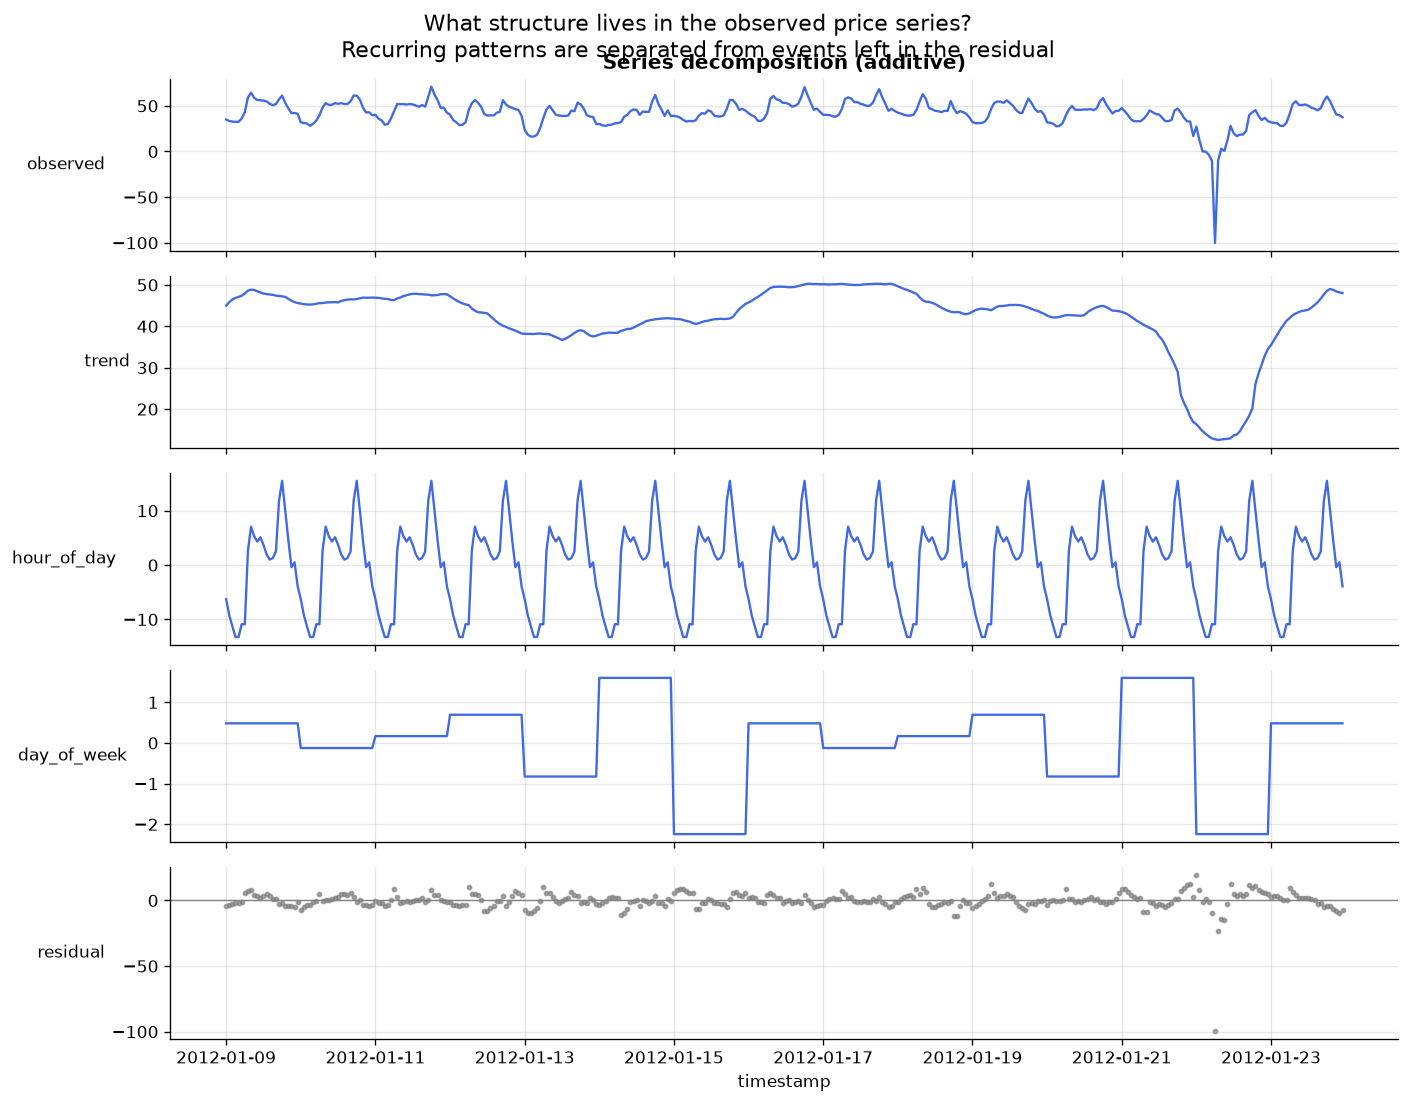

In [10]:
decomposition = explainer.decompose(
    electricity,
    features=["hour_of_day", "day_of_week"],
    period=24,
)

fig = plot_decomposition(decomposition)
fig.set_size_inches(12, 9)
fig.suptitle(
    "What structure lives in the observed price series?\n"
    "Recurring patterns are separated from events left in the residual",
    y=1.02, fontsize=13,
)
plt.show()

## Reading the Explanations Together

*Each view answers a different question.*

- **Partial dependence** shows the average response shape for one input at a time.
- **Window SHAP** shows which feature groups push forecasts up or down, and when their influence changes.
- **Decomposition** shows the recurring structure and exceptional events in the observed target.

These tools enable us to explain the forecasts generated by TabPFN and make better decisions. Try it out for yourself!